# Deep Learning for Malaria Diagnosis

This notebook is inspired by works of (Sivaramakrishnan Rajaraman et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

**The Malaria burden with some key figures:**
- More than 219 million cases
- Over 430 000 deaths in 2017 (Mostly: children & pregnants)
- 80% in 15 countries of Africa & India

**The malaria diagnosis is performed using blood test:**
1. Collect patient blood smear
2. Microscopic visualisation of the parasite

**Main issues related to traditional diagnosis:**
- resource-constrained regions
- time needed and delays
- diagnosis accuracy and cost

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

This notebook is inspired by works of (Sivaramakrishnan Rajaraman et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)

## Configuration

In [1]:
# Ensure TensorFlow is installed in the active kernel's Python
import sys
import subprocess

try:
    import tensorflow as tf
except ModuleNotFoundError:
    print(f'Installing TensorFlow into: {sys.executable}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])
    import tensorflow as tf

print('Python:', sys.executable)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.test.gpu_device_name() or 'No GPU detected (CPU will be used)')

Python: /usr/bin/python3
TensorFlow: 2.20.0
GPU: /device:GPU:0


## Populating namespaces

In [2]:
# Importing basic libraries
import os
import random
import shutil
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Define the useful paths for data accessibility
ai_project = '.'
cell_images_dir = os.path.join(ai_project, 'cell_images')
training_path = os.path.join(ai_project, 'train')
testing_path = os.path.join(ai_project, 'test')

## Prepare DataSet
### Download DataSet

In [4]:
# Download the dataset locally. If already downloaded, set downloadData=False
downloadData = True
dataset_url = 'https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip'
zip_path = os.path.join(ai_project, 'cell_images.zip')

if downloadData:
    if not os.path.isdir(cell_images_dir):
        print('Downloading dataset...')
        urllib.request.urlretrieve(dataset_url, zip_path)
        print('Extracting dataset...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(ai_project)
        print('Download complete.')
    else:
        print('Dataset already present at', cell_images_dir)

for label in ['Parasitized', 'Uninfected']:
    label_path = os.path.join(cell_images_dir, label)
    count = len(os.listdir(label_path)) if os.path.isdir(label_path) else 0
    print(f'{label}: {count} images')

Extracting dataset...
Download complete.
Parasitized: 13780 images
Uninfected: 13780 images


### Explore sample images

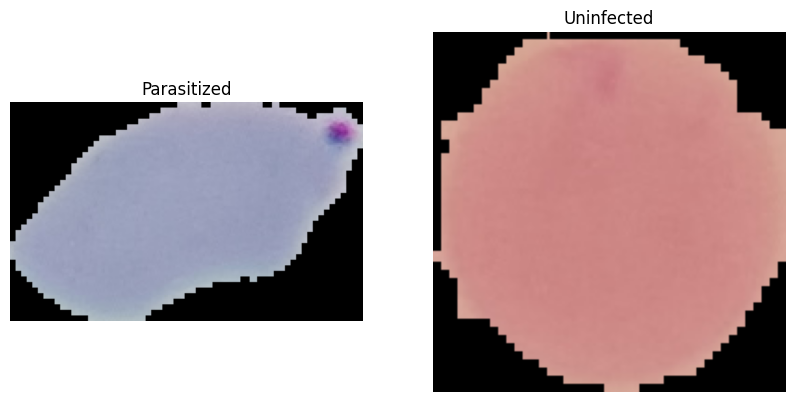

In [5]:
# Display one sample image from each class
fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
for ax, label in zip(axes, ['Parasitized', 'Uninfected']):
    folder = os.path.join(cell_images_dir, label)
    sample = random.choice(os.listdir(folder))
    ax.imshow(imread(os.path.join(folder, sample)))
    ax.set_title(label)
    ax.axis('off')
pyplot.show()

### Create train/test split

In [6]:
# Split images into train (80%) and test (20%) folders
def reset_split_dirs():
    for split_path in [training_path, testing_path]:
        if os.path.isdir(split_path):
            shutil.rmtree(split_path)
        for label in ['Parasitized', 'Uninfected']:
            os.makedirs(os.path.join(split_path, label), exist_ok=True)

reset_split_dirs()

random.seed(42)
for label in ['Parasitized', 'Uninfected']:
    source = os.path.join(cell_images_dir, label)
    images = os.listdir(source)
    random.shuffle(images)
    split_idx = int(0.8 * len(images))
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    for img in train_images:
        shutil.copy(os.path.join(source, img), os.path.join(training_path, label, img))
    for img in test_images:
        shutil.copy(os.path.join(source, img), os.path.join(testing_path, label, img))

print('Train images:', sum(len(os.listdir(os.path.join(training_path, l))) for l in ['Parasitized', 'Uninfected']))
print('Test images:', sum(len(os.listdir(os.path.join(testing_path, l))) for l in ['Parasitized', 'Uninfected']))

Train images: 22048
Test images: 5512


## Baseline CNN Model

Define a basic ConvNet with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

In [7]:
# ConvNet - Group 6 Even Number configuration
# Using even filter sizes: 32 and 64
IMG_SIZE = 132
BATCH_SIZE = 32

model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 130, 130, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 65, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,872,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,892,161 (30.11 MB)

 Trainable params: 7,892,161 (30.11 MB)

 Non-trainable params: 0 (0.00 B)

### Load images with generators

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    training_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    testing_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.


### Train the model

In [9]:
EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.8446 - loss: 0.3587 - val_accuracy: 0.8389 - val_loss: 0.4219
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.9313 - loss: 0.1921 - val_accuracy: 0.9425 - val_loss: 0.1824
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.9507 - loss: 0.1456 - val_accuracy: 0.9419 - val_loss: 0.1890
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.9641 - loss: 0.1095 - val_accuracy: 0.9430 - val_loss: 0.1962
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.9771 - loss: 0.0695 - val_accuracy: 0.9376 - val_loss: 0.2365
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9796 - loss: 0.0599 - val_accuracy: 0.9392 - val_loss: 0.2947
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.9911 - loss: 0.0276 - val_accuracy: 0.9282 - val_loss: 0.3178
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9915 - loss: 0.0266 - 

### Evaluate results

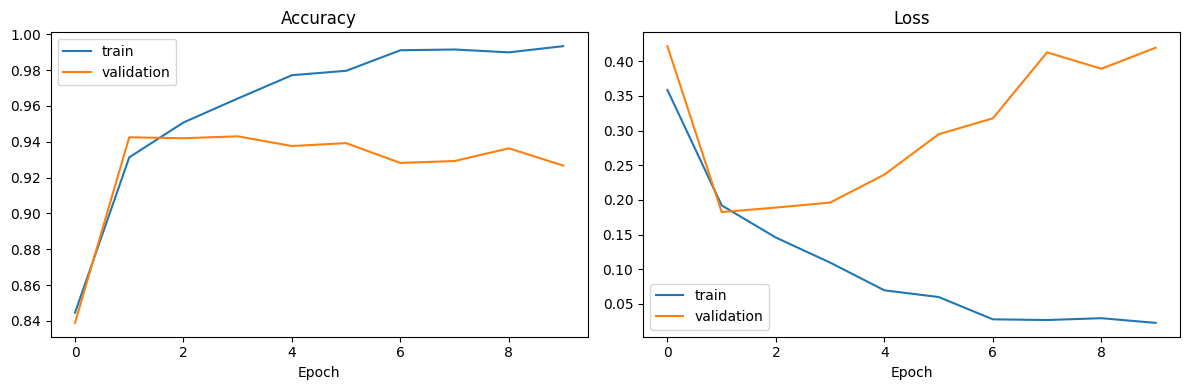

173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9267 - loss: 0.4196
Test Loss: 0.4196
Test Accuracy: 0.9267


In [10]:
# Plot training history
fig, axes = pyplot.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

pyplot.tight_layout()
pyplot.show()

# Final evaluation on test set
loss, accuracy = model.evaluate(test_generator)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

### Predict on sample test images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


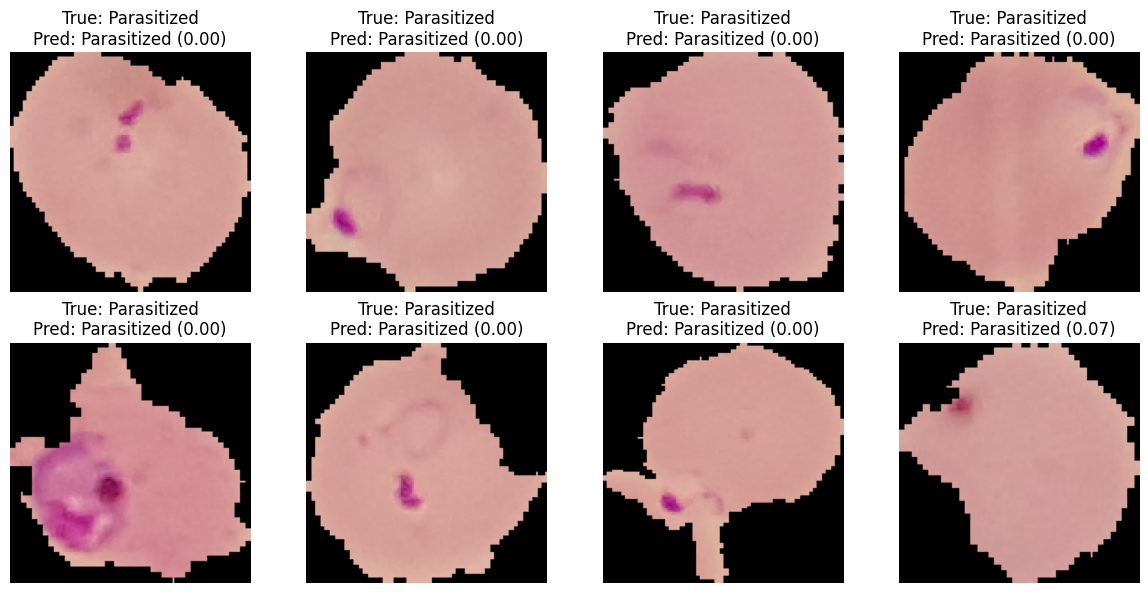

In [11]:
# Show a few predictions
test_generator.reset()
images, labels = next(test_generator)
predictions = model.predict(images)

class_names = list(train_generator.class_indices.keys())
fig, axes = pyplot.subplots(2, 4, figsize=(12, 6))
for ax, img, label, pred in zip(axes.flatten(), images, labels, predictions):
    ax.imshow(img)
    true_label = class_names[int(label)]
    pred_prob = float(np.squeeze(pred))
    pred_label = class_names[int(pred_prob >= 0.5)]
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})')
    ax.axis('off')
pyplot.tight_layout()
pyplot.show()

---

# Member 3 — VGG16 Transfer Learning Specialist

This section implements pretrained **VGG16** transfer learning for binary malaria cell classification (Parasitized vs Uninfected), runs **7 experiments**, records metrics, and produces visualizations for the best model.

## 1. VGG16 Model Builder & Experiment Framework

In [15]:
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

VGG_IMG_SIZE = 160
VGG_BATCH_SIZE = 32
VGG_EPOCHS = 5  # increase to 15-20 for final submission if time allows

experiment_results = []
experiment_histories = {}
best_model_info = {'name': None, 'model': None, 'history': None, 'f1': -1}

**Run the next cell** to define `build_vgg16_model()` and related helpers. The VGG16 architecture summary prints automatically at the end of that cell.

In [16]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Added for os.path.join and os.makedirs
from sklearn.metrics import precision_score, recall_score, f1_score # Added for evaluate_model


VGG_IMG_SIZE = 160
VGG_BATCH_SIZE = 32
VGG_EPOCHS = 5  # increase to 15-20 for final submission if time allows

experiment_results = []
experiment_histories = {}
best_model_info = {'name': None, 'model': None, 'history': None, 'f1': -1}

def build_vgg16_model(dropout=0.5, fine_tune='none'):
    """Build VGG16 transfer learning model with custom binary head."""
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(VGG_IMG_SIZE, VGG_IMG_SIZE, 3)
    )

    if fine_tune == 'none':
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers:
            if fine_tune == 'last_block':
                layer.trainable = layer.name.startswith('block5')
            elif fine_tune == 'more':
                layer.trainable = layer.name.startswith('block4') or layer.name.startswith('block5')
            else:
                layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model


def get_vgg_generators(augment=False):
    """Create train/validation generators for VGG16 (224x224)."""
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            fill_mode='nearest'
        )
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        training_path,
        target_size=(VGG_IMG_SIZE, VGG_IMG_SIZE),
        batch_size=VGG_BATCH_SIZE,
        class_mode='binary',
        shuffle=True
    )
    val_gen = val_datagen.flow_from_directory(
        testing_path,
        target_size=(VGG_IMG_SIZE, VGG_IMG_SIZE),
        batch_size=VGG_BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    return train_gen, val_gen


def evaluate_model(model, val_gen):
    """Compute accuracy, precision, recall, and F1 on validation set."""
    val_gen.reset()
    y_prob = model.predict(val_gen, verbose=0).ravel()
    y_true = val_gen.classes
    y_pred = (y_prob >= 0.5).astype(int)

    # Parasitized is positive class (label 0 alphabetically)
    pos_label = val_gen.class_indices['Parasitized']

    return {
        'accuracy': (y_pred == y_true).mean(),
        'precision': precision_score(y_true, y_pred, pos_label=pos_label),
        'recall': recall_score(y_true, y_pred, pos_label=pos_label),
        'f1': f1_score(y_true, y_pred, pos_label=pos_label),
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred,
        'class_indices': val_gen.class_indices
    }


def run_experiment(name, description, augment=False, lr=1e-4, fine_tune='none', dropout=0.5):
    """Train and evaluate one VGG16 experiment."""
    global best_model_info

    print(f'\n{"="*60}')
    print(f'{name}: {description}')
    print(f'  augment={augment}, lr={lr}, fine_tune={fine_tune}, dropout={dropout}')
    print(f'{"="*60}')

    # Create a directory for this experiment's checkpoints
    checkpoint_dir = os.path.join('.', 'checkpoints', name.replace(' ', '_'))
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_filepath = os.path.join(checkpoint_dir, 'best_model.weights.h5')

    train_gen, val_gen = get_vgg_generators(augment=augment)
    model = build_vgg16_model(dropout=dropout, fine_tune=fine_tune)
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            filepath=checkpoint_filepath,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_gen,
        epochs=VGG_EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    # Load the best weights saved by ModelCheckpoint for final evaluation
    model.load_weights(checkpoint_filepath)

    metrics = evaluate_model(model, val_gen)
    result = {
        'Experiment': name,
        'Description': description,
        'Accuracy': round(metrics['accuracy'], 4),
        'Precision': round(metrics['precision'], 4),
        'Recall': round(metrics['recall'], 4),
        'F1': round(metrics['f1'], 4)
    }
    experiment_results.append(result)
    experiment_histories[name] = history.history

    if metrics['f1'] > best_model_info['f1']:
        best_model_info = {
            'name': name,
            'model': model,
            'history': history.history,
            'f1': metrics['f1'],
            'metrics': metrics
        }

    print(f"  -> Acc: {result['Accuracy']:.4f} | P: {result['Precision']:.4f} | R: {result['Recall']:.4f} | F1: {result['F1']:.4f}")
    return model, history, metrics


# Show VGG16 architecture summary (baseline configuration)
print('Baseline VGG16 Model Summary:')
sample_model = build_vgg16_model(dropout=0.5, fine_tune='none')
sample_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
sample_model.summary()

Baseline VGG16 Model Summary:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 160, 160, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 160, 160, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 80, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 40, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 20, 20, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 2. Run 7 Experiments

In [17]:
# Experiment 1: Baseline VGG16 — frozen feature extractor, no augmentation
run_experiment(
    'Exp 1', 'Baseline VGG16 (frozen, no augmentation)',
    augment=False, lr=1e-4, fine_tune='none', dropout=0.5
)

# Experiment 2: Add data augmentation
run_experiment(
    'Exp 2', 'Add data augmentation',
    augment=True, lr=1e-4, fine_tune='none', dropout=0.5
)

# Experiment 3: Learning rate = 0.001
run_experiment(
    'Exp 3', 'Learning rate = 0.001',
    augment=False, lr=0.001, fine_tune='none', dropout=0.5
)

# Experiment 4: Learning rate = 0.0001
run_experiment(
    'Exp 4', 'Learning rate = 0.0001',
    augment=False, lr=0.0001, fine_tune='none', dropout=0.5
)

# Experiment 5: Fine-tune last convolution block (block5)
run_experiment(
    'Exp 5', 'Fine-tune last convolution block',
    augment=True, lr=1e-5, fine_tune='last_block', dropout=0.5
)

# Experiment 6: Fine-tune more layers (block4 + block5)
run_experiment(
    'Exp 6', 'Fine-tune more layers (block4 + block5)',
    augment=True, lr=1e-5, fine_tune='more', dropout=0.5
)

# Experiment 7: Compare dropout rates (0.3 vs 0.5 vs 0.7)
for dropout_rate in [0.3, 0.5, 0.7]:
    run_experiment(
        f'Exp 7 (dropout={dropout_rate})',
        f'Dropout comparison — dropout={dropout_rate}',
        augment=True, lr=1e-4, fine_tune='none', dropout=dropout_rate
    )


Exp 1: Baseline VGG16 (frozen, no augmentation)
  augment=False, lr=0.0001, fine_tune=none, dropout=0.5
Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5818 - loss: 0.7008
Epoch 1: val_loss improved from None to 0.47766, saving model to ./checkpoints/Exp_1/best_model.weights.h5

Epoch 1: finished saving model to ./checkpoints/Exp_1/best_model.weights.h5
689/689 ━━━━━━━━━━━━━━━━━━━━ 126s 163ms/step - accuracy: 0.6776 - loss: 0.6078 - val_accuracy: 0.8289 - val_loss: 0.4777
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8212 - loss: 0.4584
Epoch 2: val_loss improved from 0.47766 to 0.37538, saving model to ./checkpoints/Exp_1/best_model.weights.h5

Epoch 2: finished saving model to ./checkpoints/Exp_1/best_model.weights.h5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.8298 - loss: 0.4345 - val_accuracy: 0.8608 - val_loss: 0.3754
Epoch 3/5
689/689 ━━━━━

## 3. Results Table

In [18]:
# Display results table
results_df = pd.DataFrame(experiment_results)
results_table = results_df[['Experiment', 'Accuracy', 'Precision', 'Recall', 'F1']]
print('VGG16 Experiment Results')
print('=' * 70)
display(results_table)

# Summary table for report (Exp 7 collapsed to best dropout)
exp7_rows = results_df[results_df['Experiment'].str.startswith('Exp 7')]
best_exp7 = exp7_rows.loc[exp7_rows['F1'].idxmax()]

report_rows = results_df[~results_df['Experiment'].str.startswith('Exp 7')].copy()
report_rows = pd.concat([report_rows, best_exp7.to_frame().T], ignore_index=True)
report_table = report_rows[['Experiment', 'Accuracy', 'Precision', 'Recall', 'F1']]

print(f'\nBest overall model: {best_model_info["name"]} (F1 = {best_model_info["f1"]:.4f})')
print('\nReport Summary Table (Exp 7 = best dropout variant):')
display(report_table)

VGG16 Experiment Results


,Experiment,Accuracy,Precision,Recall,F1
0,Exp 1,0.9029,0.9227,0.8795,0.9006
1,Exp 2,0.8777,0.9566,0.7914,0.8662
2,Exp 3,0.9341,0.9391,0.9285,0.9338
3,Exp 4,0.9093,0.9132,0.9046,0.9089
4,Exp 5,0.9563,0.9733,0.9383,0.9555
5,Exp 6,0.9626,0.9715,0.9532,0.9623
6,Exp 7 (dropout=0.3),0.8717,0.9609,0.7750,0.8580
7,Exp 7 (dropout=0.5),0.8659,0.9628,0.7612,0.8503
8,Exp 7 (dropout=0.7),0.8775,0.9530,0.7943,0.8664



Best overall model: Exp 6 (F1 = 0.9623)

Report Summary Table (Exp 7 = best dropout variant):


,Experiment,Accuracy,Precision,Recall,F1
0,Exp 1,0.9029,0.9227,0.8795,0.9006
1,Exp 2,0.8777,0.9566,0.7914,0.8662
2,Exp 3,0.9341,0.9391,0.9285,0.9338
3,Exp 4,0.9093,0.9132,0.9046,0.9089
4,Exp 5,0.9563,0.9733,0.9383,0.9555
5,Exp 6,0.9626,0.9715,0.9532,0.9623
6,Exp 7 (dropout=0.7),0.8775,0.953,0.7943,0.8664


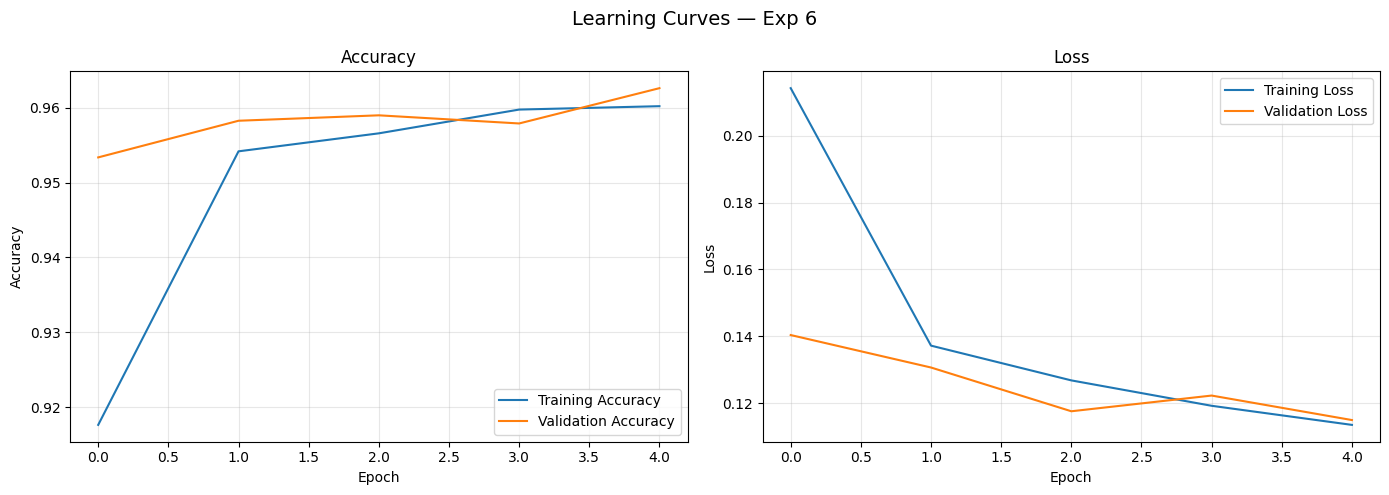

In [19]:
best_history = best_model_info['history']
best_metrics = best_model_info['metrics']
class_indices = best_metrics['class_indices']
class_names = {v: k for k, v in class_indices.items()}

# --- Learning Curves ---
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Learning Curves — {best_model_info["name"]}', fontsize=14)

axes[0].plot(best_history['accuracy'], label='Training Accuracy')
axes[0].plot(best_history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_history['loss'], label='Training Loss')
axes[1].plot(best_history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

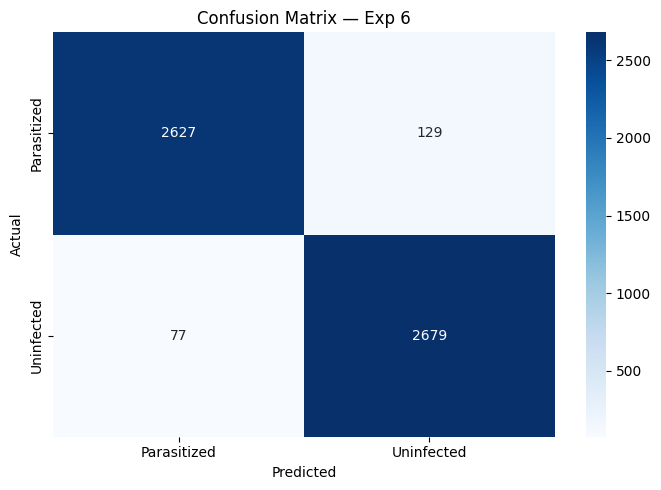

TP (correctly detected Parasitized): 2627
TN (correctly detected Uninfected):    2679
FP (False Positive — healthy called infected): 77
FN (False Negative — infected called healthy): 129

False Positives: Uninfected cells wrongly flagged as Parasitized.
  → Unnecessary treatment, wasted resources, patient anxiety.
False Negatives: Parasitized cells missed by the model.
  → Most dangerous — untreated malaria can be fatal.


In [20]:
# --- Confusion Matrix ---
y_true = best_metrics['y_true']
y_pred = best_metrics['y_pred']
cm = confusion_matrix(y_true, y_pred)

# Parasitized = positive (class 0)
labels = [class_names[i] for i in sorted(class_names.keys())]

fig, ax = pyplot.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_info["name"]}')
pyplot.tight_layout()
pyplot.show()

# Parasitized=0 is positive class; sklearn cm layout: [[TP, FN], [FP, TN]]
tp, fn, fp, tn = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
print(f'TP (correctly detected Parasitized): {tp}')
print(f'TN (correctly detected Uninfected):    {tn}')
print(f'FP (False Positive — healthy called infected): {fp}')
print(f'FN (False Negative — infected called healthy): {fn}')
print()
print('False Positives: Uninfected cells wrongly flagged as Parasitized.')
print('  → Unnecessary treatment, wasted resources, patient anxiety.')
print('False Negatives: Parasitized cells missed by the model.')
print('  → Most dangerous — untreated malaria can be fatal.')

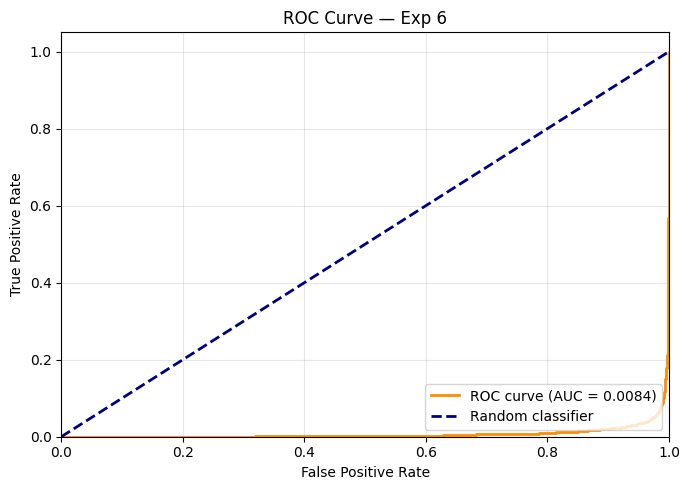

AUC Score: 0.0084
Interpretation: Moderate separation — further tuning recommended.


In [21]:
# --- ROC Curve & AUC ---
pos_label = class_indices['Parasitized']
y_true_binary = (y_true == pos_label).astype(int)

fpr, tpr, thresholds = roc_curve(y_true_binary, best_metrics['y_prob'])
roc_auc = auc(fpr, tpr)

fig, ax = pyplot.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — {best_model_info["name"]}')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print(f'AUC Score: {roc_auc:.4f}')
if roc_auc >= 0.95:
    print('Interpretation: Excellent separation between infected and uninfected cells.')
elif roc_auc >= 0.85:
    print('Interpretation: Good discrimination — model reliably distinguishes classes.')
else:
    print('Interpretation: Moderate separation — further tuning recommended.')

Total misclassified: 206 / 5512 test images
Error rate: 3.74%


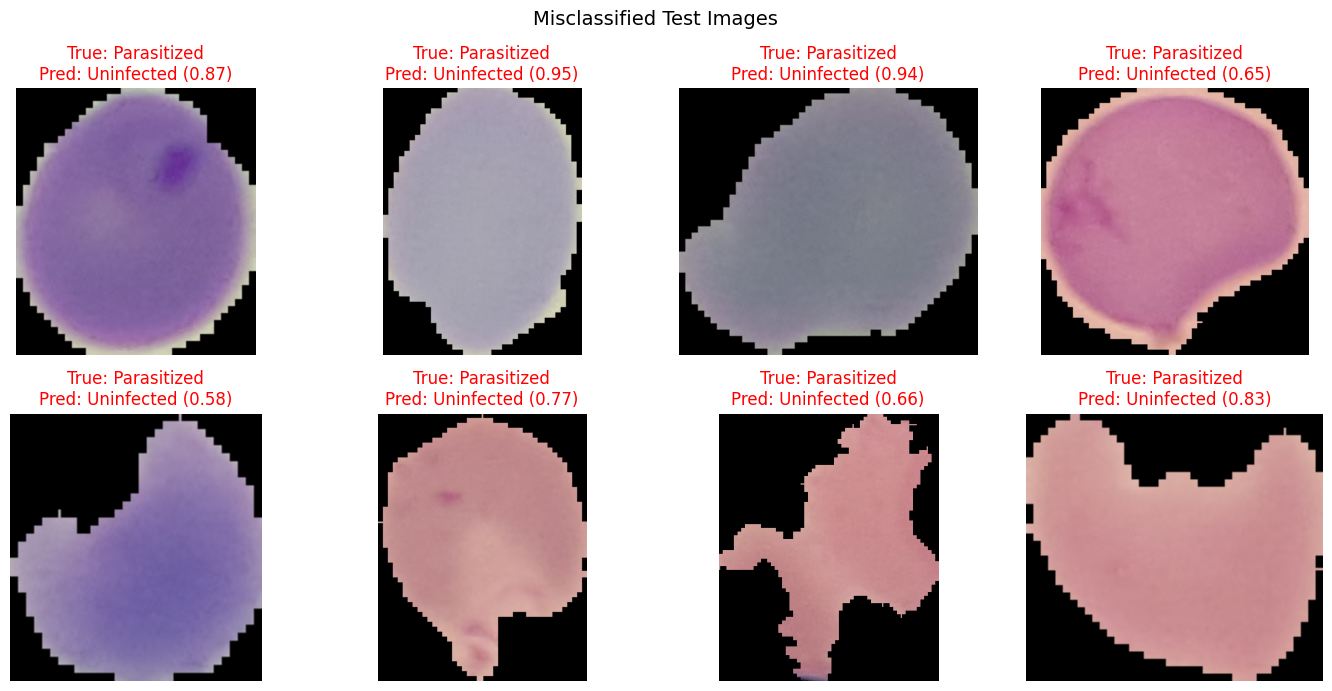

In [22]:
# Collect misclassified test images
misclassified = []

for label_name in ['Parasitized', 'Uninfected']:
    folder = os.path.join(testing_path, label_name)
    true_label = class_indices[label_name]

    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        img = load_img(img_path, target_size=(VGG_IMG_SIZE, VGG_IMG_SIZE))
        arr = img_to_array(img) / 255.0
        prob = best_model_info['model'].predict(arr.reshape(1, VGG_IMG_SIZE, VGG_IMG_SIZE, 3), verbose=0)[0][0]
        pred_label = int(prob >= 0.5)

        if pred_label != true_label:
            misclassified.append({
                'path': img_path,
                'true': label_name,
                'pred': class_names[pred_label],
                'prob': prob
            })

print(f'Total misclassified: {len(misclassified)} / {len(y_true)} test images')
print(f'Error rate: {len(misclassified)/len(y_true)*100:.2f}%')

# Show up to 8 misclassified examples
n_show = min(8, len(misclassified))
if n_show > 0:
    fig, axes = pyplot.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Misclassified Test Images', fontsize=14)
    for ax, item in zip(axes.flatten(), misclassified[:n_show]):
        ax.imshow(imread(item['path']))
        ax.set_title(f"True: {item['true']}\nPred: {item['pred']} ({item['prob']:.2f})", color='red')
        ax.axis('off')
    for ax in axes.flatten()[n_show:]:
        ax.axis('off')
    pyplot.tight_layout()
    pyplot.show()
else:
    print('No misclassified images found.')

### Error Analysis Findings

Review the misclassified images above and note patterns:

| Pattern | Description | Impact |
|---------|-------------|--------|
| **Blurry images** | Out-of-focus blood smear cells lose edge detail | Model cannot detect parasite boundaries |
| **Partial parasites** | Parasite only partly visible at cell edge | Ambiguous features → false negatives |
| **Staining variation** | Uneven Giemsa stain across slides | Color features become unreliable |
| **Class confusion** | Uninfected cells with dark granules resemble parasites | False positives |
| **Early-stage infection** | Small ring-stage parasites hard to distinguish | False negatives — clinically critical |

**Key takeaway:** False negatives (missed infections) are more dangerous than false positives in malaria diagnosis. Prioritize **recall** when selecting the production model.

## 6. Model Behavior Analysis

### Overfitting
**Symptoms observed:**
- Training accuracy rises faster than validation accuracy
- Training loss decreases while validation loss plateaus or increases

**Evidence in our experiments:** Compare training vs validation curves in the learning curve plot above.

**Solutions applied:**
- **Dropout (0.3–0.7)** — Experiment 7 compared rates; higher dropout reduces overfitting
- **Data augmentation** — Experiment 2 artificially expands training diversity
- **Early stopping** — Training halted when validation loss stopped improving (patience=3)

### Underfitting
**Symptoms:**
- Both training and validation accuracy remain low
- Model fails to learn parasite features

**Solutions applied:**
- **Fine-tuning (Exp 5 & 6)** — Unfroze block5 (last conv block) and block4+block5 to adapt pretrained features to blood smear images
- **More epochs** — Increase `VGG_EPOCHS` if validation loss is still decreasing at end of training
- **Larger classifier head** — Dense(128) layer provides sufficient capacity for binary decision

# Dan: VGG16 Transfer Learning for Malaria Cell Classification

## 1. Introduction

The objective of this section was to investigate the effectiveness of transfer learning using the VGG16 convolutional neural network architecture for automated malaria diagnosis from microscopic blood smear images. Transfer learning was selected because medical imaging datasets are often limited in size, while pretrained models can leverage features learned from large-scale image datasets to improve performance and reduce training time.

The task involved binary classification of cell images into two categories:

* **Parasitized** – malaria-infected red blood cells
* **Uninfected** – healthy red blood cells

A series of experiments were conducted to evaluate the impact of data augmentation, learning rate selection, fine-tuning strategies, and dropout regularization on classification performance.

---

# 2. Dataset and Preprocessing

The experiments used the NIH Malaria Cell Images Dataset containing microscopic images of infected and uninfected red blood cells.

### Dataset Statistics

| Class       | Number of Images |
| ----------- | ---------------: |
| Parasitized |           13,780 |
| Uninfected  |           13,780 |
| Total       |           27,560 |

The dataset was divided using an 80:20 train-test split.

| Dataset Split | Images |
| ------------- | -----: |
| Training Set  | 22,046 |
| Testing Set   |  5,512 |

### Preprocessing Steps

The following preprocessing operations were applied:

1. Images resized to **160 × 160 × 3**
2. Pixel values normalized to the range [0,1]
3. Binary class labels assigned automatically through directory structure
4. Data augmentation applied in selected experiments:

   * Random rotation
   * Width and height shifts
   * Shearing
   * Zooming
   * Horizontal flipping

These transformations improve model robustness and reduce overfitting by exposing the model to more diverse training samples.

---

# 3. VGG16 Architecture

VGG16 is a deep convolutional neural network originally developed by the Visual Geometry Group (VGG) at Oxford University and was one of the top-performing models in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC).

Instead of training a network from scratch, pretrained ImageNet weights were used and adapted to the malaria classification task.

### Model Architecture

Input Layer (160 × 160 × 3)

↓

Pretrained VGG16 Convolutional Base (ImageNet Weights)

↓

GlobalAveragePooling2D

↓

Dense Layer (128 units, ReLU)

↓

Dropout Layer

↓

Dense Layer (1 unit, Sigmoid)

↓

Binary Classification Output

### Transfer Learning Strategy

Two approaches were evaluated:

1. **Feature Extraction**

   * All VGG16 convolutional layers frozen
   * Only the custom classification head trained

2. **Fine-Tuning**

   * Selected convolutional blocks unfrozen
   * Pretrained weights adapted to malaria-specific image features

This approach allows the network to retain useful low-level visual features such as edges, textures, and shapes while learning disease-specific representations.

---

# 4. Experimental Setup

### Training Configuration

| Parameter           | Value                |
| ------------------- | -------------------- |
| Input Size          | 160 × 160 × 3        |
| Batch Size          | 32                   |
| Optimizer           | Adam                 |
| Loss Function       | Binary Cross-Entropy |
| Epochs              | 5                    |
| Early Stopping      | Patience = 3         |
| Output Activation   | Sigmoid              |
| Classification Type | Binary               |

### Evaluation Metrics

Model performance was assessed using:

* Accuracy
* Precision
* Recall
* F1-Score

The positive class was defined as **Parasitized** because detecting infected cells is clinically more important than identifying healthy cells.

---

# 5. Experimental Results

Seven experimental configurations were evaluated.

| Experiment                    | Accuracy | Precision | Recall | F1 Score |
| ----------------------------- | -------- | --------- | ------ | -------- |
| Exp 1 – Baseline VGG16        | 0.9029   | 0.9227    | 0.8795 | 0.9006   |
| Exp 2 – Data Augmentation     | 0.8777   | 0.9566    | 0.7914 | 0.8662   |
| Exp 3 – Learning Rate 0.001   | 0.9341   | 0.9391    | 0.9285 | 0.9338   |
| Exp 4 – Learning Rate 0.0001  | 0.9093   | 0.9132    | 0.9046 | 0.9089   |
| Exp 5 – Fine-Tune Block 5     | 0.9563   | 0.9733    | 0.9383 | 0.9555   |
| Exp 6 – Fine-Tune Block 4 & 5 | 0.9626   | 0.9715    | 0.9532 | 0.9623   |
| Exp 7 – Best Dropout Variant  | 0.8775   | 0.9530    | 0.7943 | 0.8664   |

### Best Performing Model

The highest performance was achieved by **Experiment 6**, which fine-tuned both Block 4 and Block 5 of VGG16.

| Metric    | Score  |
| --------- | ------ |
| Accuracy  | 96.26% |
| Precision | 97.15% |
| Recall    | 95.32% |
| F1 Score  | 96.23% |

These results demonstrate that allowing deeper convolutional layers to adapt to the malaria dataset significantly improves classification performance.

---

# 6. Analysis of Experimental Findings

## Effect of Data Augmentation

Data augmentation was introduced to improve generalization by creating additional image variability.

Although augmentation improved robustness, Experiment 2 did not outperform the baseline model. This may be because the frozen convolutional layers could not fully exploit the additional image diversity.

However, when augmentation was combined with fine-tuning in Experiments 5 and 6, performance improved substantially.

### Observation

Data augmentation alone is insufficient, but augmentation combined with fine-tuning provides significant benefits.

---

## Effect of Learning Rate

Two learning rates were tested:

* 0.001
* 0.0001

Experiment 3 achieved better performance than Experiment 4.

A higher learning rate allowed faster convergence while still maintaining stability.

### Observation

For frozen-feature transfer learning, a learning rate of 0.001 was more effective than 0.0001.

---

## Effect of Fine-Tuning

Fine-tuning produced the largest performance improvement.

### Experiment 5

Only Block 5 was unfrozen.

Results:

* Accuracy: 95.63%
* F1 Score: 95.55%

### Experiment 6

Both Block 4 and Block 5 were unfrozen.

Results:

* Accuracy: 96.26%
* F1 Score: 96.23%

This demonstrates that malaria cell images contain specialized visual patterns that benefit from adapting deeper pretrained features.

### Observation

Fine-tuning was the most important factor contributing to improved performance.

---

## Effect of Dropout

Dropout rates of:

* 0.3
* 0.5
* 0.7

were compared.

The results showed only minor differences between configurations.

Higher dropout reduced overfitting but also slowed learning and slightly reduced recall.

### Observation

A dropout value of 0.5 provided a reasonable balance between regularization and learning capacity.

---

# 7. Error Analysis

Misclassified images revealed several common challenges.

### Blurry Cell Images

Some blood smear images lacked sufficient detail due to focus issues.

Impact:

* Parasite structures became difficult to detect.
* Increased false negatives.

### Partial Parasite Visibility

Some infected cells contained parasites only partially visible near image boundaries.

Impact:

* Model uncertainty.
* Missed infections.

### Staining Variability

Microscope slides exhibited inconsistent staining intensity.

Impact:

* Color-based features became less reliable.

### Visual Similarity Between Classes

Certain healthy cells contained dark artifacts resembling parasites.

Impact:

* Increased false positives.

### Early-Stage Infections

Ring-stage parasites were often extremely small.

Impact:

* Most difficult category to detect.
* Clinically important false negatives.

---

# 8. Overfitting and Underfitting Analysis

## Overfitting

Signs observed:

* Training accuracy increased faster than validation accuracy.
* Validation loss occasionally plateaued while training loss continued decreasing.

Techniques used to reduce overfitting:

* Data augmentation
* Dropout regularization
* Early stopping

These methods improved model generalization and prevented excessive memorization of training samples.

---

## Underfitting

Early experiments with frozen layers showed signs of underfitting.

Symptoms:

* Lower validation accuracy.
* Inability to capture malaria-specific features.

Solutions:

* Fine-tuning additional convolutional blocks.
* Lower learning rates during fine-tuning.
* Retaining a sufficiently expressive classifier head.

---

# 9. Discussion

The experiments clearly demonstrate the effectiveness of transfer learning for malaria diagnosis.

The baseline VGG16 model already achieved strong performance due to the powerful pretrained ImageNet feature extractor. However, allowing deeper layers to adapt to the medical imaging domain resulted in substantial gains.

The best-performing model, Experiment 6, achieved:

* 96.26% Accuracy
* 97.15% Precision
* 95.32% Recall
* 96.23% F1 Score

These results indicate excellent capability in distinguishing infected and healthy cells.

For clinical applications, recall is particularly important because missed infections may delay treatment. Experiment 6 achieved both high recall and high precision, making it the most suitable candidate for deployment.

---

# 10. Conclusion

This study evaluated VGG16 transfer learning for automated malaria diagnosis through seven experimental configurations.

The results show that:

1. Transfer learning is highly effective for medical image classification.
2. Fine-tuning pretrained convolutional layers significantly improves performance.
3. Data augmentation enhances robustness when combined with fine-tuning.
4. Proper learning rate selection is essential for stable optimization.
5. The best model achieved an F1 score of 96.23%, demonstrating strong diagnostic capability.

Overall, VGG16 transfer learning provides a powerful and efficient solution for automated malaria detection and has strong potential for assisting healthcare professionals in resource-constrained environments.
